   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.2 MB/s eta 0:00:00
Mounted at /content/drive
Found 255 images belonging to 5 classes.
Found 125 images belonging to 5 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 241s 14s/step - accuracy: 0.4353 - loss: 1.3417 - val_accuracy: 0.5840 - val_loss: 0.9097
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 691ms/step - accuracy: 0.6667 - loss: 0.8084 - val_accuracy: 0.5600 - val_loss: 0.8869
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 629ms/step - accuracy: 0.7412 - loss: 0.6243 - val_accuracy: 0.7120 - val_loss: 0.7596
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 662ms/step - accuracy: 0.8157 - loss: 0.5089 - val_accuracy: 0.7600 - val_loss: 0.6747
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 703ms/step - accuracy: 0.8392 - loss: 0.4256 - val_accuracy: 0.7440 - val_loss: 0.6686
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 301ms/step - accuracy:

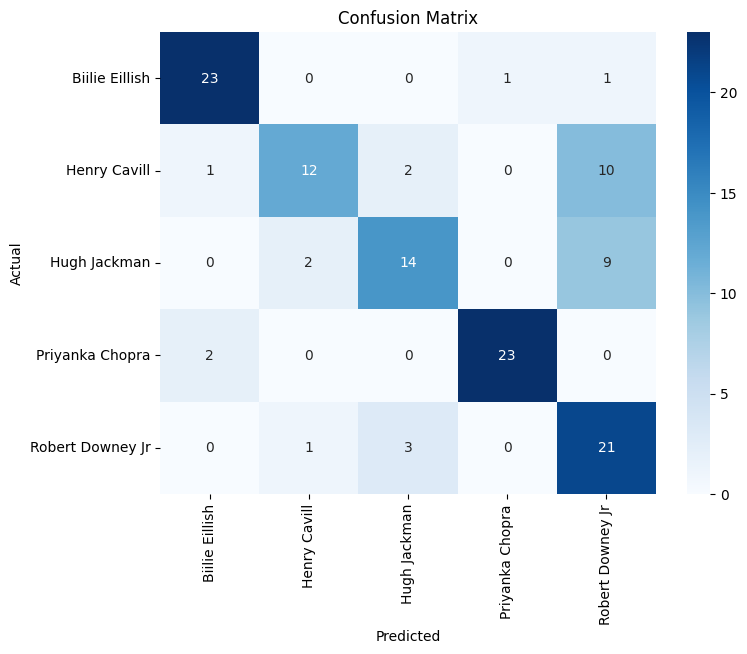

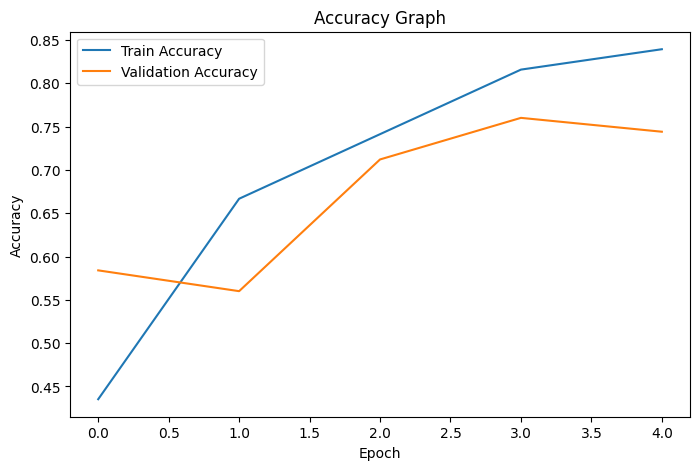

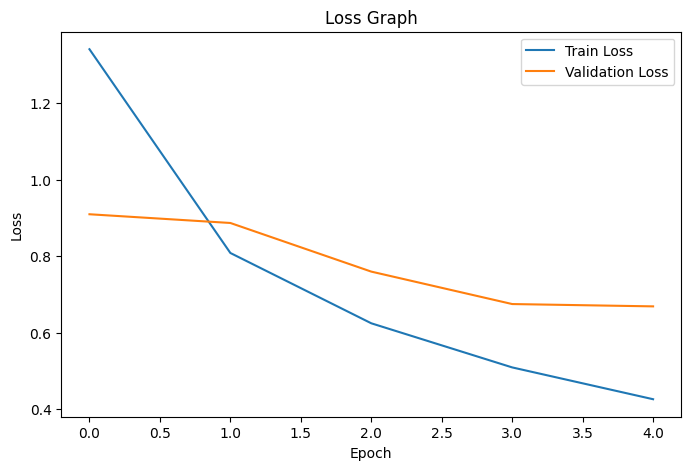


Upload Face Image


Saving rdj.jpg to rdj.jpg


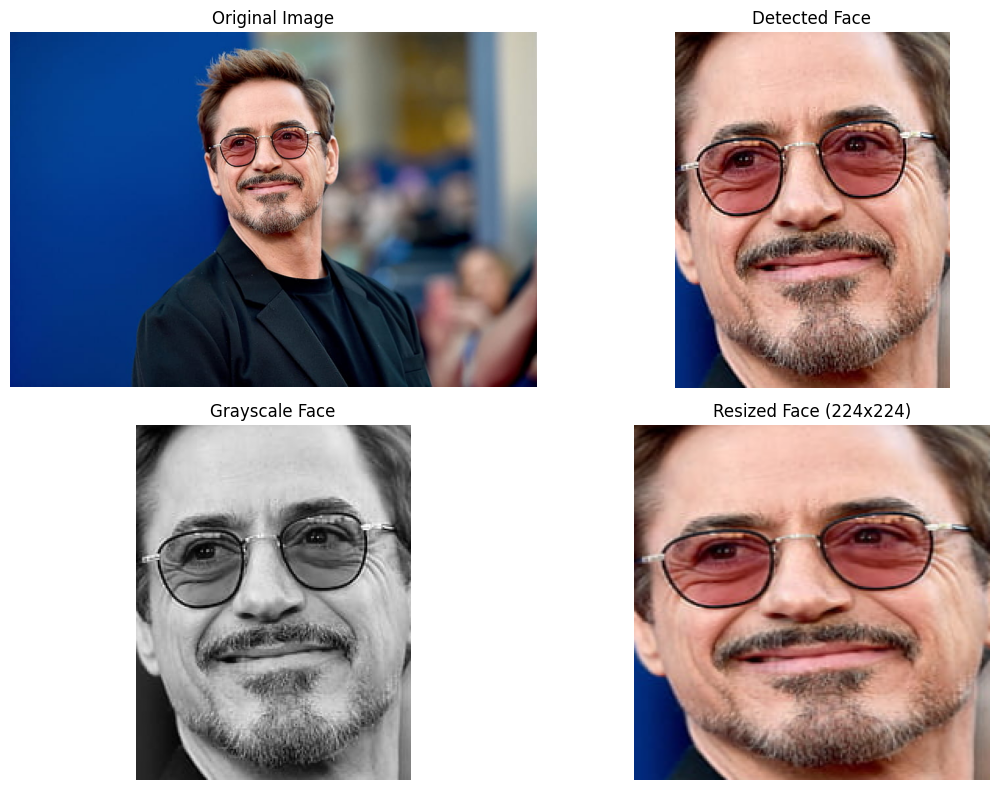

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step



Prediction Confidence: [[0.01144079 0.02111398 0.04452766 0.02361941 0.89929813]]
Recognized Person: Robert Downey Jr

Model Saved Successfully


In [1]:
# Install Libraries
!pip install -q mtcnn scikit-learn seaborn opencv-python

# 1. IMPORT LIBRARIES
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

from google.colab import drive, files

from mtcnn import MTCNN
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

# 2. MOUNT DRIVE
drive.mount('/content/drive')


# 3. DATASET PATH
train_path = '/content/drive/MyDrive/dataset_fr/train'
test_path  = '/content/drive/MyDrive/dataset_fr/test'

# 4. IMAGE PREPROCESSING
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

# 5. LOAD PRETRAINED MODEL
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# 6. BUILD MODEL
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(train_data.num_classes, activation='softmax')
])

# 7. COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 8. TRAIN MODEL
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

# 9. EVALUATE MODEL
loss, accuracy = model.evaluate(test_data)

print("\nTest Accuracy:", round(accuracy*100,2), "%")
print("Test Loss:", round(loss,4))

# 10. PREDICTIONS
pred = model.predict(test_data)
pred_classes = np.argmax(pred, axis=1)
true_classes = test_data.classes

class_names = list(test_data.class_indices.keys())

# 11. CLASSIFICATION REPORT
print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_names))

# 12. CONFUSION MATRIX
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 13. ACCURACY GRAPH
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 14. LOSS GRAPH
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 15. UPLOAD FACE IMAGE FOR TESTING
print("\nUpload Face Image")
uploaded = files.upload()

img_name = list(uploaded.keys())[0]

# 16. LOAD IMAGE
img = cv2.imread(img_name)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 17. FACE DETECTION USING MTCNN
detector = MTCNN()
faces = detector.detect_faces(img_rgb)

if len(faces) == 0:
    print("No face detected.")
else:
    x, y, w, h = faces[0]['box']
    x, y = abs(x), abs(y)

    face = img_rgb[y:y+h, x:x+w]

    # Grayscale
    gray = cv2.cvtColor(face, cv2.COLOR_RGB2GRAY)

    # Resize
    resized = cv2.resize(face, (224,224))

    # Normalize
    normalized = resized / 255.0

    # 18. DISPLAY PROCESSING STAGES
    plt.figure(figsize=(12,8))

    plt.subplot(2,2,1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(face)
    plt.title("Detected Face")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale Face")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(resized)
    plt.title("Resized Face (224x224)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # 19. FINAL PREDICTION
    input_img = np.expand_dims(normalized, axis=0)

    prediction = model.predict(input_img)
    pred_class = np.argmax(prediction)

    print("\nPrediction Confidence:", prediction)
    print("Recognized Person:", class_names[pred_class])

# 20. SAVE MODEL
model.save("face_recognition_model.h5")
print("\nModel Saved Successfully")